# CNN with Batchnorm

- 3 convolutional blocks:
    - Conv2D → ReLU → MaxPooling
- Channel progression: 3 → 32 → 64 → 128

**Objective** <br/>
Evaluate whether adding Batch Normalization improves training stability and model performance.

**Changes from baseline** <br/>
- Added BatchNorm2d after each Conv2d layer
- Kept CNN architecture unchanged

**Hypothesis** <br/>
Batch Normalization will stabilize training, improve convergence, and lead to better generalization performance.

### 1. Import libraries

In [1]:
import sys
import os
from pathlib import Path

# Find project root regardless of CWD (works in VS Code, Jupyter Lab, etc.)
ROOT = next(p for p in [Path.cwd()] + list(Path.cwd().parents) if (p / 'src').exists())
sys.path.insert(0, str(ROOT))

import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt

from src.data.dataloader import get_dataloaders
from src.models.cnn_batchnorm import BatchNormCNN
from src.training.trainer import train_one_epoch, validate_one_epoch


from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

os.chdir(ROOT)
print(Path.cwd())

/Users/joelyeo/Desktop/Deep Learning/Project/50.039-Deep-Learning


### 2. Use Cuda else MPS

In [2]:
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Using device: {device}')

Using device: mps


### 3. Split Dataset 
- Use batchNorm model
- Use BCEWithLogitsLoss
- Use Adam optimizer

In [3]:
train_loader, val_loader, test_loader = get_dataloaders(
    train_csv='data_new/splits/train.csv',
    val_csv='data_new/splits/val.csv',
    test_csv='data_new/splits/test.csv',
    image_dir='data_new/images/train',
    test_image_dir='data_new/images/test',
    batch_size=32,
    image_size=224,
    num_workers=0,
)

train_df = pd.read_csv("data_new/splits/train.csv")

num_melanoma = (train_df["label"] == 1).sum()  # CSV melanoma
num_nevus = (train_df["label"] == 0).sum()     # CSV nevus

pos_weight = torch.tensor([num_nevus / num_melanoma], dtype=torch.float32).to(device)

print("pos_weight:", pos_weight)

model = BatchNormCNN().to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

pos_weight: tensor([8.1117], device='mps:0')


### 4. Train Model

In [4]:
model_save_path = os.path.abspath("models/cnn_batchnorm_weighted.pth")
os.makedirs(os.path.dirname(model_save_path), exist_ok=True)

num_epochs = 20

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
##########
train_f2s = []
val_f2s = []
##########

best_val_f2 = -1.0

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_metrics = validate_one_epoch(model, val_loader, criterion, device)

    train_losses.append(train_metrics["loss"])
    val_losses.append(val_metrics["loss"])
    train_accuracies.append(train_metrics["accuracy"])
    val_accuracies.append(val_metrics["accuracy"])
    ##########
    train_f2s.append(train_metrics["f2"])
    val_f2s.append(val_metrics["f2"])
    ##########

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {train_metrics['loss']:.4f}, Train Acc: {train_metrics['accuracy']:.4f}, Train F2: {train_metrics['f2']:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f}, Val Acc: {val_metrics['accuracy']:.4f}, Val F2: {val_metrics['f2']:.4f}"
    )

    if val_metrics["f2"] > best_val_f2:
        best_val_f2 = val_metrics["f2"]
        torch.save(model.state_dict(), model_save_path)
        print("Saved best model at epoch", epoch + 1)

Epoch [1/20] | Train Loss: 4.3370, Train Acc: 0.5812, Train F2: 0.4594 | Val Loss: 0.9730, Val Acc: 0.5222, Val F2: 0.5238
Saved best model at epoch 1


Epoch [2/20] | Train Loss: 1.0239, Train Acc: 0.5784, Train F2: 0.5000 | Val Loss: 0.9647, Val Acc: 0.6181, Val F2: 0.5482
Saved best model at epoch 2


Epoch [3/20] | Train Loss: 1.0209, Train Acc: 0.5789, Train F2: 0.5056 | Val Loss: 0.9700, Val Acc: 0.5642, Val F2: 0.5283


Epoch [4/20] | Train Loss: 1.0388, Train Acc: 0.5645, Train F2: 0.5058 | Val Loss: 1.2488, Val Acc: 0.3384, Val F2: 0.4620


Epoch [5/20] | Train Loss: 1.1026, Train Acc: 0.6283, Train F2: 0.4959 | Val Loss: 0.9487, Val Acc: 0.5741, Val F2: 0.5395


...

Epoch [16/20] | Train Loss: 1.0284, Train Acc: 0.7680, Train F2: 0.5242 | Val Loss: 0.9853, Val Acc: 0.6986, Val F2: 0.5776
Saved best model at epoch 16


Epoch [17/20] | Train Loss: 1.0115, Train Acc: 0.7729, Train F2: 0.5383 | Val Loss: 0.9555, Val Acc: 0.6986, Val F2: 0.5754


Epoch [18/20] | Train Loss: 0.9891, Train Acc: 0.7689, Train F2: 0.5578 | Val Loss: 0.9679, Val Acc: 0.7599, Val F2: 0.5841
Saved best model at epoch 18


Epoch [19/20] | Train Loss: 0.9463, Train Acc: 0.7747, Train F2: 0.5725 | Val Loss: 0.9866, Val Acc: 0.7722, Val F2: 0.5581


Epoch [20/20] | Train Loss: 0.9361, Train Acc: 0.7783, Train F2: 0.5733 | Val Loss: 0.9369, Val Acc: 0.7105, Val F2: 0.5858
Saved best model at epoch 20


### 5. Plot Loss and Accuracy Curves

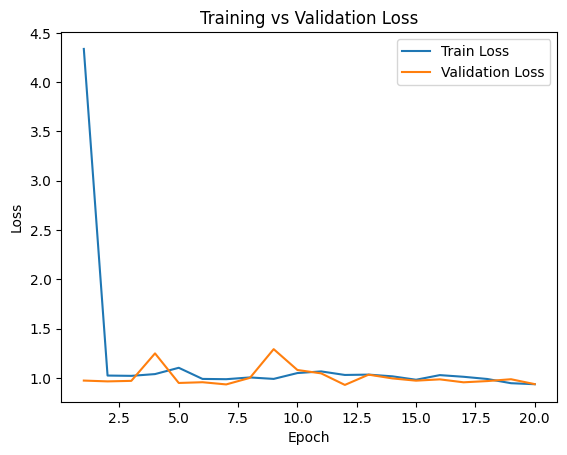

In [5]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure()
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

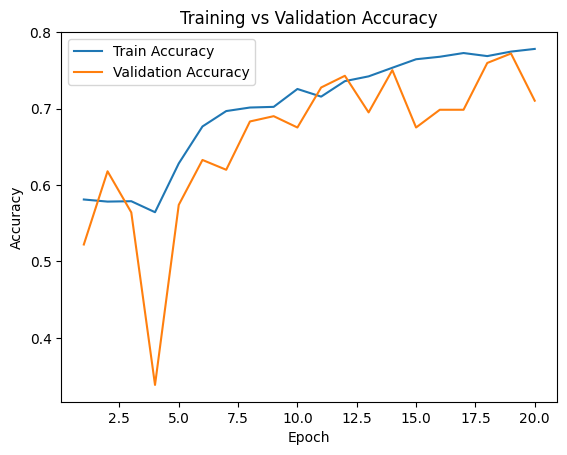

In [6]:
plt.figure()
plt.plot(epochs, train_accuracies, label="Train Accuracy")
plt.plot(epochs, val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

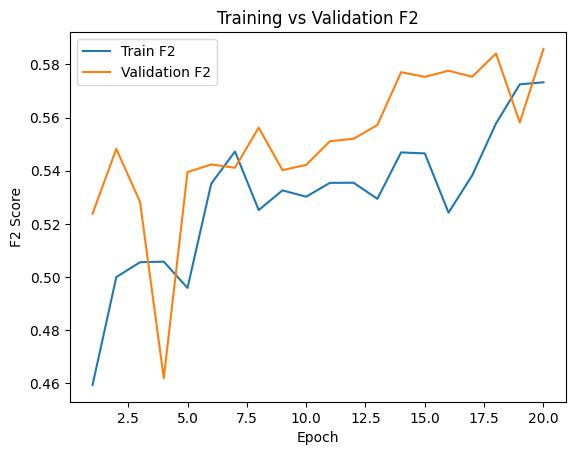

In [7]:
plt.figure()
plt.plot(epochs, train_f2s, label="Train F2")
plt.plot(epochs, val_f2s, label="Validation F2")

plt.xlabel("Epoch")
plt.ylabel("F2 Score")
plt.title("Training vs Validation F2")
plt.legend()
plt.show()

### 6. Evaluate model
[[TN, FP],<BR/>
 [FN, TP]]

- TN: correctly predicted non-melanoma
- FP: benign predicted as melanoma
- FN: melanoma missed
- TP: correctly predicted melanoma

Precision → “When the model says YES, how often is it correct?” <br/>
Recall → “Out of all actual YES, how many did we catch?”

In [8]:
from sklearn.metrics import fbeta_score, precision_score, recall_score, balanced_accuracy_score
import numpy as np

model.eval()

val_labels = []
val_probs = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.sigmoid(outputs).squeeze(1)

        val_labels.extend(labels.numpy())
        val_probs.extend(probs.cpu().numpy())

thresholds = np.arange(0.05, 0.95, 0.05)

best_threshold = 0.5
best_f2 = -1

for threshold in thresholds:
    preds = [1 if p >= threshold else 0 for p in val_probs]
    f2 = fbeta_score(val_labels, preds, beta=2)

    print(
        f"Threshold={threshold:.2f} | "
        f"F2={f2:.4f} | "
        f"Precision={precision_score(val_labels, preds):.4f} | "
        f"Recall={recall_score(val_labels, preds):.4f} | "
        f"Balanced Acc={balanced_accuracy_score(val_labels, preds):.4f}"
    )

    if f2 > best_f2:
        best_f2 = f2
        best_threshold = threshold

print(f"\nBest threshold on validation set: {best_threshold:.2f}")


Threshold=0.05 | F2=0.3977 | Precision=0.1167 | Recall=1.0000 | Balanced Acc=0.5003
Threshold=0.10 | F2=0.3991 | Precision=0.1172 | Recall=1.0000 | Balanced Acc=0.5031
Threshold=0.15 | F2=0.4016 | Precision=0.1184 | Recall=1.0000 | Balanced Acc=0.5084
Threshold=0.20 | F2=0.4048 | Precision=0.1200 | Recall=0.9958 | Balanced Acc=0.5158
Threshold=0.25 | F2=0.4066 | Precision=0.1213 | Recall=0.9873 | Balanced Acc=0.5216
Threshold=0.30 | F2=0.5488 | Precision=0.2034 | Recall=0.9534 | Balanced Acc=0.7303
Threshold=0.35 | F2=0.5685 | Precision=0.2220 | Recall=0.9322 | Balanced Acc=0.7505
Threshold=0.40 | F2=0.5755 | Precision=0.2361 | Recall=0.8983 | Balanced Acc=0.7573
Threshold=0.45 | F2=0.5732 | Precision=0.2469 | Recall=0.8559 | Balanced Acc=0.7557
Threshold=0.50 | F2=0.5858 | Precision=0.2654 | Recall=0.8390 | Balanced Acc=0.7662
Threshold=0.55 | F2=0.5930 | Precision=0.2888 | Recall=0.8051 | Balanced Acc=0.7717
Threshold=0.60 | F2=0.5845 | Precision=0.3105 | Recall=0.7500 | Balanced Acc

#### 7. Use best threshold

In [9]:
model.eval()

all_labels = []
all_probs = []
all_preds = []

threshold = best_threshold

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)                      # raw logits
        probs = torch.sigmoid(outputs).squeeze(1)    # probabilities
        preds = (probs >= threshold).long()            # binary predictions

        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

In [10]:
cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:")
print(cm)

print(classification_report(all_labels, all_preds, digits=4))

Confusion Matrix:
[[965 375]
 [ 42 129]]
              precision    recall  f1-score   support

           0     0.9583    0.7201    0.8223      1340
           1     0.2560    0.7544    0.3822       171

    accuracy                         0.7240      1511
   macro avg     0.6071    0.7373    0.6023      1511
weighted avg     0.8788    0.7240    0.7725      1511



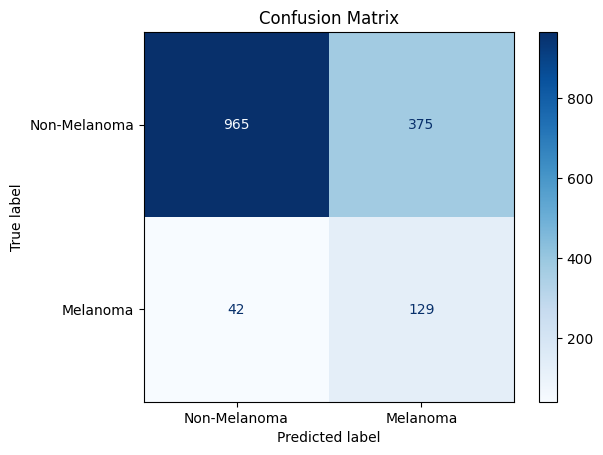

In [11]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Melanoma", "Melanoma"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

- The BatchNorm-weighted CNN introduces batch normalization after each convolutional layer while retaining class-weighted loss, and it further tunes the decision threshold using F2-score to prioritize recall. 
- This model achieves higher melanoma recall of 75.44%, improving from 61.99% in the previous weighted baseline, and reduces false negatives from 65 to 42. 
- However, this comes at the expense of a large increase in false positives, from 180 to 375, causing overall accuracy to fall to 72.40% and melanoma precision to drop to 25.60%. 
- The training and validation curves do not show strong overfitting, since the train-validation gap remains limited, but they are noisy and only moderately strong, suggesting underfitting or insufficient model capacity. 
- Overall, the model is learning useful patterns, especially for melanoma detection, but the architecture still appears too simple to achieve a good balance between sensitivity and precision.

| Model | Main Change | Accuracy | Melanoma Precision | Melanoma Recall | Melanoma F1 | Main Takeaway |
|---|---|---:|---:|---:|---:|---|
| `01.cnn_baseline` | Plain CNN, no weighting | 0.8848 | 0.4848 | 0.2807 | 0.3556 | Looks accurate overall, but misses many melanomas |
| `02.cnn_baseline_weighted` | Added `pos_weight`, tuned threshold by F1 | 0.8379 | 0.3706 | 0.6199 | 0.4639 | Much better melanoma detection, better balance overall |
| `03.cnn_batchnorm_weighted` | Added BatchNorm, weighted loss, tuned threshold by F2 | 0.7240 | 0.2560 | 0.7544 | 0.3822 | Highest recall, but too many false positives |